## Importing Libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

## Importing and preprocessing the dataset

In [2]:
df = pd.read_csv("clickbait_data.csv")
df.dropna(inplace=True)
df.rename(columns={'clickbait': 'label'}, inplace=True)
df['label'] = df['label'].map({0: 'real', 1: 'clickbait'})

In [3]:
print(df.shape)
df.head()

(32000, 2)


,headline,label
0,Should I Get Bings,clickbait
1,Which TV Female Friend Group Do You Belong In,clickbait
2,"The New ""Star Wars: The Force Awakens"" Trailer...",clickbait
3,"This Vine Of New York On ""Celebrity Big Brothe...",clickbait
4,A Couple Did A Stunning Photo Shoot With Their...,clickbait


## Train-Test Split

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['headline'], df['label'], test_size=0.2, random_state=42, stratify=df['label']) 

In [5]:
y_test.value_counts(normalize=True) # Used Stratify for proportional distribution

label
real         0.5
clickbait    0.5
Name: proportion, dtype: float64

In [6]:
y_train.value_counts(normalize=True)

label
real         0.500039
clickbait    0.499961
Name: proportion, dtype: float64

In [7]:
print(f"Train : {len(X_train)}, Test : {len(X_test)}")

Train : 25600, Test : 6400


## Feature Extraction with TF-IDF

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_vec.shape}")

Feature matrix shape: (25600, 5000)


## Training Random Forest Model

In [9]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
classifier.fit(X_train_vec, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

## Evaluation of the test (Random Forest)

In [10]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

y_pred = classifier.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 91.45%
              precision    recall  f1-score   support

   clickbait       0.89      0.95      0.92      3200
        real       0.94      0.88      0.91      3200

    accuracy                           0.91      6400
   macro avg       0.92      0.91      0.91      6400
weighted avg       0.92      0.91      0.91      6400



## Plotting confusion Matrix

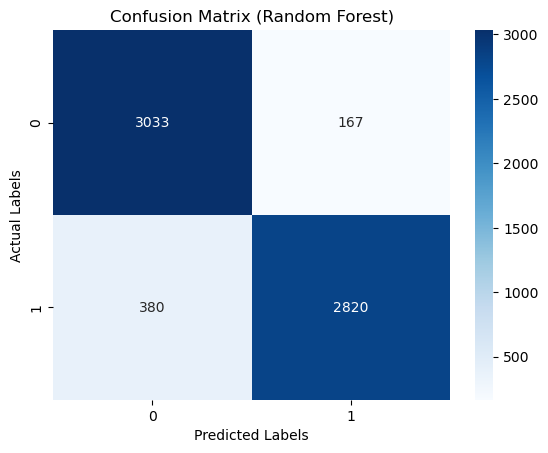

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Random Forest)")
plt.ylabel('Actual Labels')        # y-axis label (true values)
plt.xlabel('Predicted Labels')     # x-axis label (predicted values)
plt.show()

## Training K-Nearest Neighbors Model

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_cl = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2, n_jobs=-1)
knn_cl.fit(X_train_vec, y_train)

KNeighborsClassifier(n_jobs=-1)

## Evaluation of the test (KNN)

In [13]:
y_pred_knn = knn_cl.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")
# Classification Report
print(classification_report(y_test, y_pred_knn))

Accuracy: 63.02%
              precision    recall  f1-score   support

   clickbait       0.58      0.90      0.71      3200
        real       0.78      0.36      0.50      3200

    accuracy                           0.63      6400
   macro avg       0.68      0.63      0.60      6400
weighted avg       0.68      0.63      0.60      6400



## Plotting confusion Matrix (KNN)

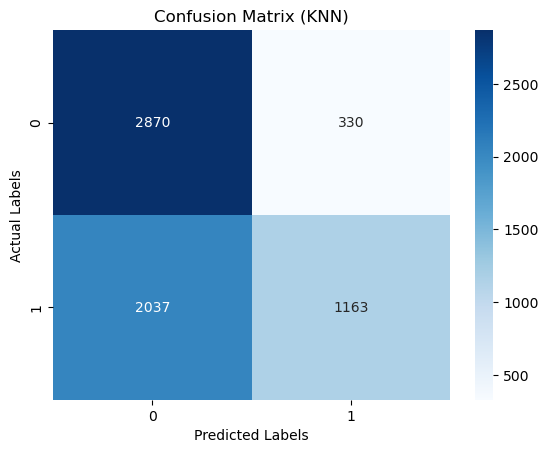

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (KNN)")
plt.ylabel('Actual Labels')        # y-axis label (true values)
plt.xlabel('Predicted Labels')     # x-axis label (predicted values)
plt.show()

## Training Support Vector Machine Model

In [14]:
from sklearn.svm import SVC
svm_cl = SVC(kernel='rbf', random_state=0)
svm_cl.fit(X_train_vec, y_train)

SVC(random_state=0)

## Evaluation of the test (SVM)

In [15]:
y_pred_svm = svm_cl.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
# Classification Report
print(classification_report(y_test, y_pred_svm))

Accuracy: 95.72%
              precision    recall  f1-score   support

   clickbait       0.97      0.95      0.96      3200
        real       0.95      0.97      0.96      3200

    accuracy                           0.96      6400
   macro avg       0.96      0.96      0.96      6400
weighted avg       0.96      0.96      0.96      6400



## Training Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_cl = DecisionTreeClassifier(criterion='gini', splitter='best', min_samples_split=2)
dt_cl.fit(X_train_vec, y_train)

DecisionTreeClassifier()

## Evaluation of the test (Decision Tree)

In [30]:
y_pred_dt = dt_cl.predict(X_test_vec)
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%")
# Classification Report
print(classification_report(y_test, y_pred_dt))

Accuracy: 88.02%
              precision    recall  f1-score   support

   clickbait       0.85      0.93      0.89      3200
        real       0.92      0.83      0.87      3200

    accuracy                           0.88      6400
   macro avg       0.88      0.88      0.88      6400
weighted avg       0.88      0.88      0.88      6400

